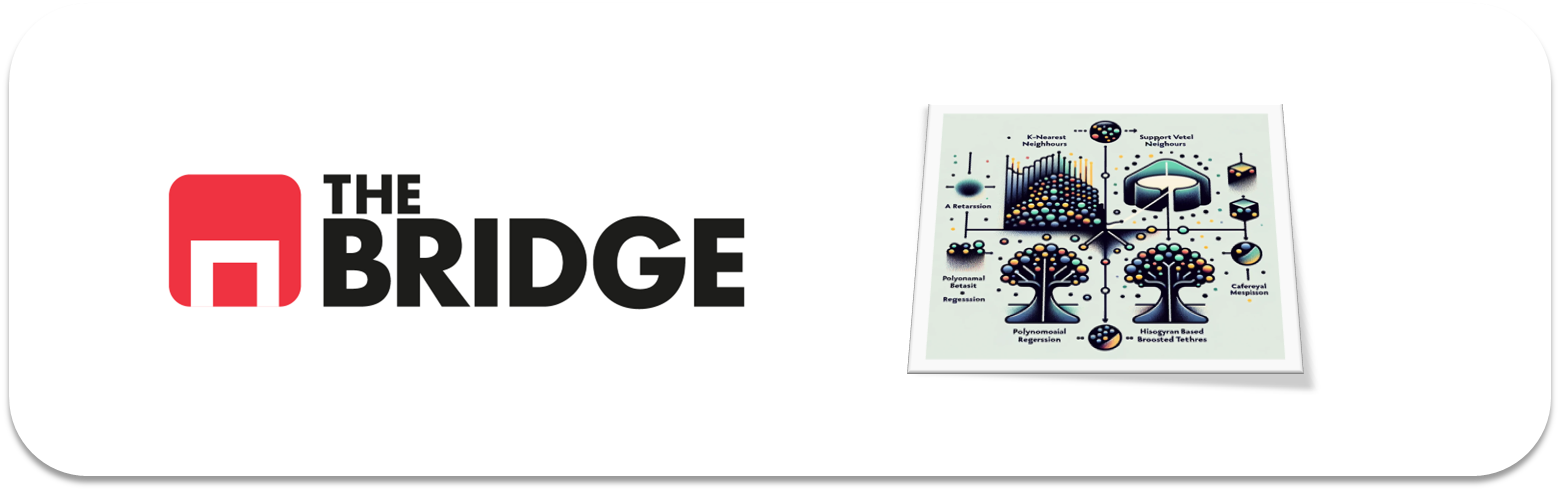

## PRACTICA OBLIGATORIA: **Otros Modelos Supervisados**

* La práctica obligatoria de esta unidad consiste en resolver un modelado de clasificación, incluyendo KNN entre los posibles modelos, y aplicando balanceado. Para ello utilizaremos un dataset que ya hemos empleado en los workout. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [2]:
# Librerías básicas
import warnings
import numpy as np
import pandas as pd

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns
import bootcampviztools as bt

# Preprocesado, split y validación
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score,
    RandomizedSearchCV,
)
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Balanceo de clases (dentro del pipeline, sólo aplicado a train en cada fold)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# Modelos
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Métricas
from sklearn.metrics import (
    balanced_accuracy_score, accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report, RocCurveDisplay,
)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
np.random.seed(42)
SEED = 42

### #1. El problema y los datos

Vamos a volver al dataset con el que vimos la clasificación binaria con regresión logística, "Give me some credit", y nuestro objetivo es crear un modelo que nos permita predicir si una persona va a encontrarse en dificultades financieras en los dos próximos años. El dataset de partida lo puedes en contrar en el directorio data que acompaña al ejercicio. 

### #1.1
Cárgalo y, apoyándote en las herramientas y fuentes que consideres necesarias, haz una descripción textual de sus variables. Luego con ayuda de los datos, haz una clasificación inicial de sus variables en categóricas y numéricas.

**Carga y descripción de variables**

El dataset es el "Give Me Some Credit" (Kaggle), con 150.000 clientes y 11 columnas, **todas numéricas** (no hay variables categóricas que codificar):

- **`SeriousDlqin2yrs`** *(target)*: 1 si la persona sufrió un impago grave (90+ días de mora) en los siguientes 2 años, 0 en caso contrario.
- **`RevolvingUtilizationOfUnsecuredLines`**: ratio entre el saldo dispuesto de tarjetas/líneas de crédito no garantizadas y la suma de sus límites. Numérica continua (debería estar entre 0 y 1, aunque veremos que hay valores anómalos).
- **`age`**: edad del cliente. Numérica discreta.
- **`NumberOfTime30-59DaysPastDueNotWorse`**: nº de veces que se ha retrasado 30-59 días en un pago (sin llegar a peor) en los últimos 2 años. Numérica discreta (conteo).
- **`DebtRatio`**: ratio de pagos de deuda / ingresos mensuales. Numérica continua.
- **`MonthlyIncome`**: ingreso mensual. Numérica continua.
- **`NumberOfOpenCreditLinesAndLoans`**: nº de préstamos y líneas de crédito abiertas. Numérica discreta.
- **`NumberOfTimes90DaysLate`**: nº de veces con retraso de 90+ días. Numérica discreta.
- **`NumberRealEstateLoansOrLines`**: nº de préstamos hipotecarios/inmobiliarios. Numérica discreta.
- **`NumberOfTime60-89DaysPastDueNotWorse`**: nº de veces con retraso de 60-89 días. Numérica discreta.
- **`NumberOfDependents`**: nº de personas a cargo del cliente. Numérica discreta.

En resumen: **1 target binario + 10 predictoras numéricas** (mezcla de ratios continuos y conteos discretos), sin variables categóricas propiamente dichas.

### #1.2
¿Qué tipo de problema estamos tratando? ¿Cuál es la variable target?

**Tipo de problema y target**

Es un problema de **clasificación binaria supervisada**: queremos predecir si un cliente tendrá dificultades financieras graves (impago de 90+ días) en los próximos dos años. El target es `SeriousDlqin2yrs` (1 = sí tendrá problemas serios, 0 = no).

### #1.3
Pinta la distribución de frecuencias del target y coméntala

In [3]:
url = "https://raw.githubusercontent.com/jxchen/Kaggle/master/Give%20Me%20Some%20Credit/cs-training.csv"
df = pd.read_csv(url, index_col=0)
print(df.shape)
df.head()

(150000, 11)


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


### #2 Modelado

Realiza un proceso completo de modelado hasta dar con el mejor modelo de los que hayas escogido (emplea al menos 3, y uno tiene que ser KNN). Aplica las técnicas que creas necesarias para obtener el mejor resultado (suponiendo que este después de hablar con el negocio es el recall medio, para tener un compromiso entre las dos clases). Para comparar modelos emplea validación cruzada antes de optimización y luego ajusta los hiperparámetros del mejor modelo. Evalúa este y haz un pequeño análisis de errores.

SeriousDlqin2yrs
0    139974
1     10026
Name: count, dtype: int64
SeriousDlqin2yrs
0    0.93316
1    0.06684
Name: proportion, dtype: float64


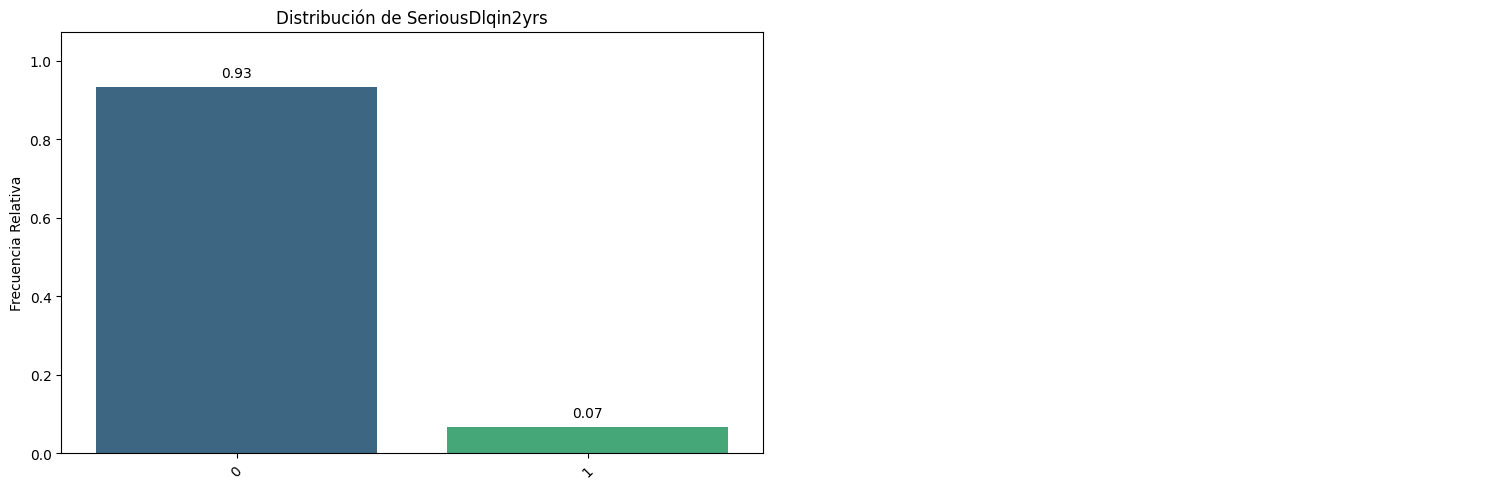

In [4]:
print(df["SeriousDlqin2yrs"].value_counts())
print(df["SeriousDlqin2yrs"].value_counts(normalize=True))

bt.pinta_distribucion_categoricas(df, ["SeriousDlqin2yrs"], relativa=True, mostrar_valores=True)

El target está **muy desbalanceado**: solo un 6.7% de los clientes tuvo un impago grave, frente a un 93.3% que no. Es un desbalanceo mucho más marcado que en ejercicios anteriores, así que el balanceo de clases (pedido explícitamente en el enunciado) va a ser clave, y usaremos **recall medio (balanced accuracy)** como métrica principal, tal y como indica el enunciado ("el recall medio, para tener un compromiso entre las dos clases").

### #2.1 Exploración adicional (mini EDA)

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeriousDlqin2yrs,150000.0,0.066840,0.249746,0.0,0.000000,0.000000,0.000000,1.0
RevolvingUtilizationOfUnsecuredLines,150000.0,6.048438,249.755371,0.0,0.029867,0.154181,0.559046,50708.0
age,150000.0,52.295207,14.771866,0.0,41.000000,52.000000,63.000000,109.0
NumberOfTime30-59DaysPastDueNotWorse,150000.0,0.421033,4.192781,0.0,0.000000,0.000000,0.000000,98.0
DebtRatio,150000.0,353.005076,2037.818523,0.0,0.175074,0.366508,0.868254,329664.0
MonthlyIncome,120269.0,6670.221237,14384.674215,0.0,3400.000000,5400.000000,8249.000000,3008750.0
NumberOfOpenCreditLinesAndLoans,150000.0,8.452760,5.145951,0.0,5.000000,8.000000,11.000000,58.0
NumberOfTimes90DaysLate,150000.0,0.265973,4.169304,0.0,0.000000,0.000000,0.000000,98.0
NumberRealEstateLoansOrLines,150000.0,1.018240,1.129771,0.0,0.000000,1.000000,2.000000,54.0
NumberOfTime60-89DaysPastDueNotWorse,150000.0,0.240387,4.155179,0.0,0.000000,0.000000,0.000000,98.0


Antes de modelar merece la pena fijarse en varias cosas "raras" en los datos, típicas de este dataset (son problemas de calidad de datos conocidos y documentados en la comunidad):

- `RevolvingUtilizationOfUnsecuredLines` y `DebtRatio` deberían moverse en rangos razonables (idealmente entre 0 y pocas unidades) pero tienen máximos absurdos (decenas de miles). Son outliers/errores de captura.
- Las tres columnas de morosidad (`NumberOfTime30-59...`, `NumberOfTime60-89...`, `NumberOfTimes90DaysLate`) tienen valores **96 y 98** que no son conteos reales, sino códigos especiales (probablemente "dato erróneo"/"no aplica"). Aparecen siempre en las mismas filas.
- Hay al menos un cliente con `age = 0`, imposible.
- `MonthlyIncome` y `NumberOfDependents` tienen valores faltantes (NaN).

Vamos a confirmarlo:

In [ ]:
cols_impagos = ["NumberOfTime30-59DaysPastDueNotWorse",
                "NumberOfTime60-89DaysPastDueNotWorse",
                "NumberOfTimes90DaysLate"]

for c in cols_impagos:
    print(c, "-> nº de 96/98:", df[c].isin([96, 98]).sum())

print("age == 0:", (df["age"] == 0).sum())
print("duplicados:", df.duplicated().sum())
print()
print("Nulos:")
print(df.isna().sum())

NumberOfTime30-59DaysPastDueNotWorse -> nº de 96/98: 269
NumberOfTime60-89DaysPastDueNotWorse -> nº de 96/98: 269
NumberOfTimes90DaysLate -> nº de 96/98: 269
age == 0: 1
duplicados: 609

Nulos:
SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64


(4, 2)


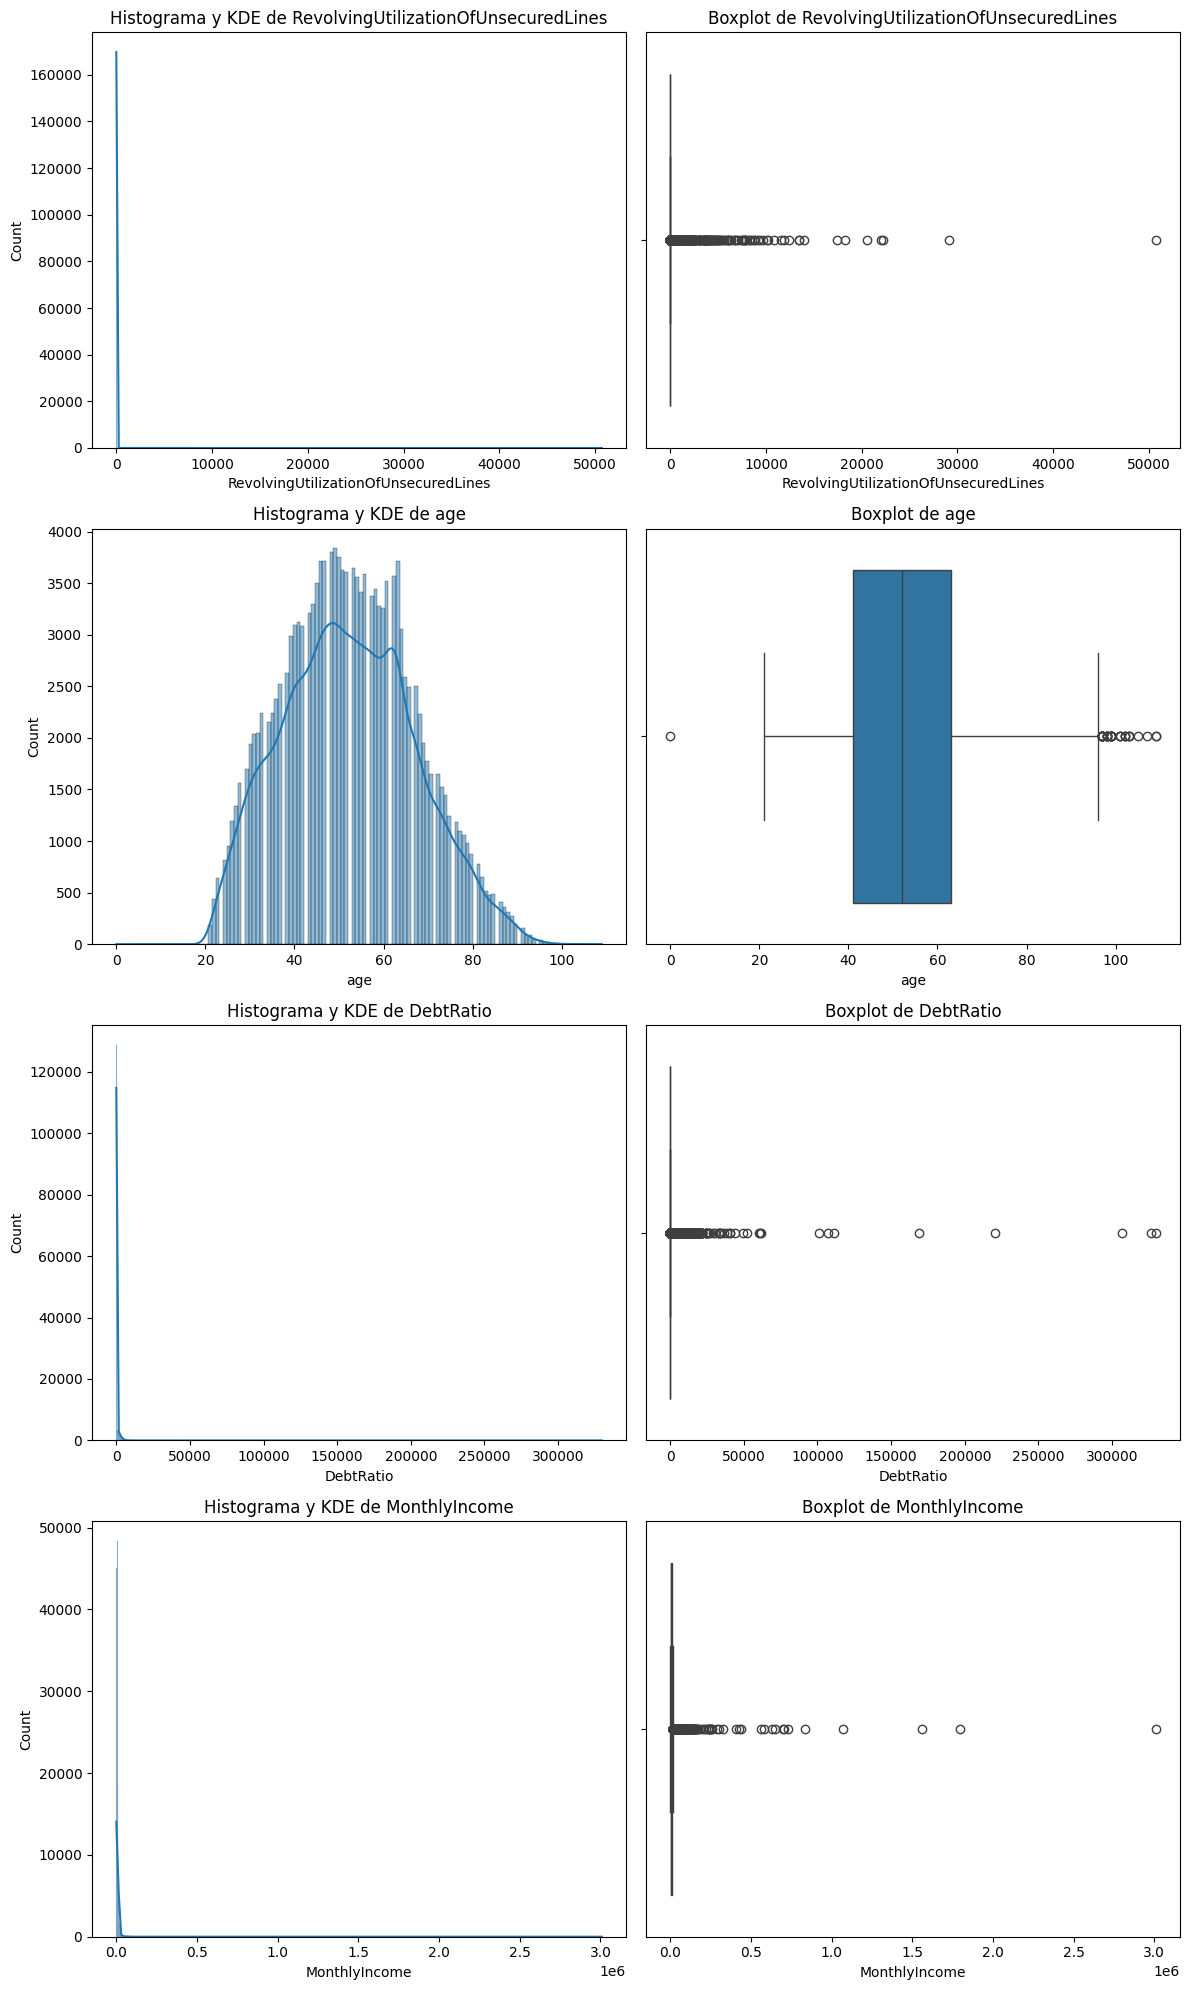

In [ ]:
bt.plot_combined_graphs(df, ["RevolvingUtilizationOfUnsecuredLines", "age", "DebtRatio", "MonthlyIncome"])

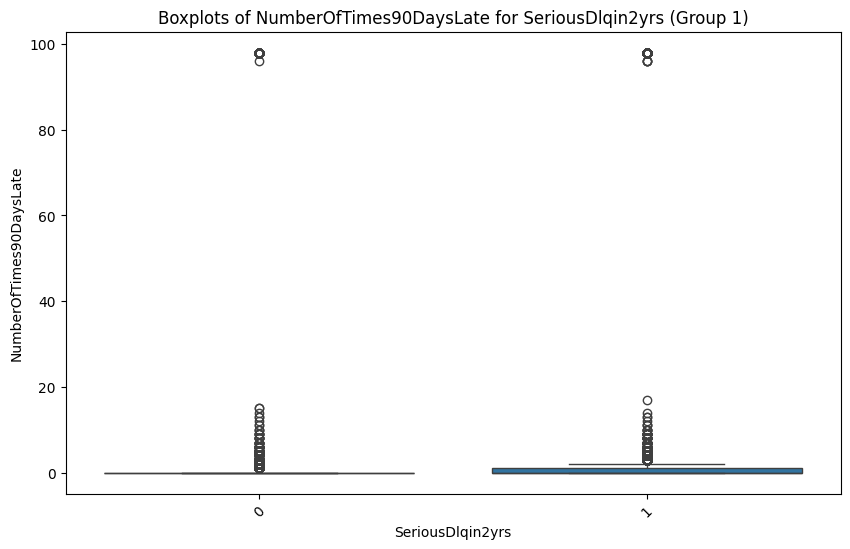

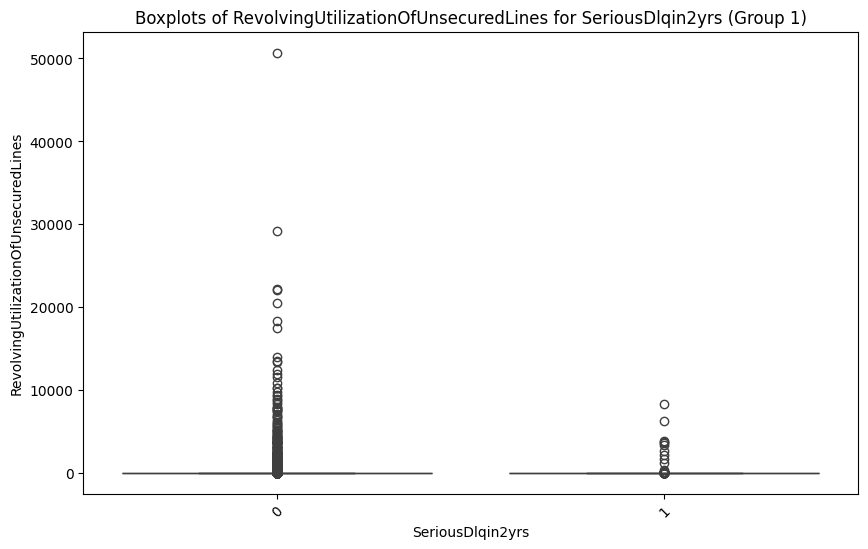

In [ ]:
bt.plot_grouped_boxplots(df, "SeriousDlqin2yrs", "NumberOfTimes90DaysLate")
bt.plot_grouped_boxplots(df, "SeriousDlqin2yrs", "RevolvingUtilizationOfUnsecuredLines")

Se aprecia que los clientes con impago grave (`SeriousDlqin2yrs = 1`) tienden a tener más morosidad previa y mayor utilización de sus líneas de crédito, tal y como cabría esperar. Con esto ya podemos pasar a limpiar los datos.

### #2.2 Limpieza

- Quitamos duplicados.
- Los códigos 96/98 en las columnas de morosidad los convertimos en `NaN` (no son conteos reales).
- `age = 0` lo convertimos en `NaN`.
- Los outliers extremos de `RevolvingUtilizationOfUnsecuredLines` y `DebtRatio` los capamos (winsorizamos) al percentil 99, para no dejar que unos pocos valores absurdos distorsionen el escalado (crítico para KNN) sin perder la información de que son valores altos.
- El resto de `NaN` (incluyendo los generados arriba, más los ya existentes en `MonthlyIncome` y `NumberOfDependents`) los imputamos con la mediana **dentro del pipeline**, para que se calcule solo con datos de train en cada fold y evitar fuga de información.

In [ ]:
df_clean = df.drop_duplicates().copy()
print("Filas tras quitar duplicados:", df_clean.shape[0], f"(se han quitado {df.shape[0] - df_clean.shape[0]})")

for c in cols_impagos:
    df_clean[c] = df_clean[c].replace([96, 98], np.nan)

df_clean["age"] = df_clean["age"].replace(0, np.nan)

for c in ["RevolvingUtilizationOfUnsecuredLines", "DebtRatio"]:
    cap = df_clean[c].quantile(0.99)
    df_clean[c] = df_clean[c].clip(upper=cap)

df_clean.isna().sum()

Filas tras quitar duplicados: 149391 (se han quitado 609)


SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         1
NumberOfTime30-59DaysPastDueNotWorse      225
DebtRatio                                   0
MonthlyIncome                           29221
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                   225
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse      225
NumberOfDependents                       3828
dtype: int64

In [ ]:
X = df_clean.drop(columns=["SeriousDlqin2yrs"])
y = df_clean["SeriousDlqin2yrs"]

X.head()

,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,0.766127,45.0,2.0,0.802982,9120.0,13,0.0,6,0.0,2.0
2,0.957151,40.0,0.0,0.121876,2600.0,4,0.0,0,0.0,1.0
3,0.658180,38.0,1.0,0.085113,3042.0,2,1.0,0,0.0,0.0
4,0.233810,30.0,0.0,0.036050,3300.0,5,0.0,0,0.0,0.0
5,0.907239,49.0,1.0,0.024926,63588.0,7,0.0,1,0.0,0.0


### #2.3 Train / Test split

Reservamos el test (20%, estratificado) antes de comparar u optimizar nada, como en las prácticas anteriores.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print("Train:", X_train.shape, " Test:", X_test.shape)
print("Proporción positivos train:", y_train.mean().round(4))
print("Proporción positivos test :", y_test.mean().round(4))

Train: (119512, 10)  Test: (29879, 10)
Proporción positivos train: 0.067
Proporción positivos test : 0.067


### #2.4 El desequilibrio importa: una demostración rápida

Antes de meternos con los 3 modelos, veamos con un caso rápido (regresión logística, muy rápida de entrenar) qué pasa si **no** hacemos nada contra el desequilibrio de clases:

In [ ]:
from sklearn.pipeline import Pipeline

pipe_sin_balancear = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, random_state=SEED)),
])
pipe_sin_balancear.fit(X_train, y_train)
y_pred_sb = pipe_sin_balancear.predict(X_test)
print(classification_report(y_test, y_pred_sb, target_names=["no problemas", "impago grave"]))

              precision    recall  f1-score   support

no problemas       0.94      0.99      0.97     27877
impago grave       0.60      0.17      0.26      2002

    accuracy                           0.94     29879
   macro avg       0.77      0.58      0.61     29879
weighted avg       0.92      0.94      0.92     29879



Sin balancear, el modelo apenas "capta" al 20% de los clientes que realmente van a tener un impago grave (recall bajísimo en la clase 1), aunque el accuracy global parezca alto (porque acierta casi siempre con la clase mayoritaria). Justo el problema que el enunciado nos pide evitar optimizando el **recall medio**. Vamos a aplicar balanceo de clases con **SMOTE** (sobremuestreo sintético de la clase minoritaria), metido dentro de un `Pipeline` de `imblearn` para que solo se aplique sobre los datos de entrenamiento de cada fold.

### #2.5 Modelos: KNN + al menos otros dos

Elegimos 3 modelos (el enunciado exige mínimo 3, con KNN obligatorio):

- **KNN** (`KNeighborsClassifier`) — obligatorio. Sensible a la escala, así que escalamos con `StandardScaler`.
- **Regresión Logística** (`LogisticRegression`) — como referencia/baseline lineal, rápida de entrenar incluso con 150k filas.
- **Random Forest** (`RandomForestClassifier`) — ensemble de árboles, no necesita escalado.

Los tres llevan `SimpleImputer` (mediana) y `SMOTE` dentro del pipeline.

In [ ]:
def make_pipe(clf, con_escalado):
    pasos = [("imputer", SimpleImputer(strategy="median"))]
    if con_escalado:
        pasos.append(("scaler", StandardScaler()))
    pasos += [("smote", SMOTE(random_state=SEED)), ("clf", clf)]
    return ImbPipeline(pasos)

models = {
    "KNN": make_pipe(KNeighborsClassifier(n_jobs=-1), con_escalado=True),
    "LogisticRegression": make_pipe(LogisticRegression(max_iter=1000, random_state=SEED), con_escalado=True),
    "RandomForest": make_pipe(RandomForestClassifier(random_state=SEED, n_jobs=-1), con_escalado=False),
}

### #2.6 Comparación con validación cruzada (sin optimizar, sin tocar test)

`cv=3` (por tiempo de cómputo, con 150k filas 3 folds ya son representativos) y `scoring="balanced_accuracy"`, que es exactamente el recall medio de las dos clases que pide el enunciado.

In [ ]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

resultados_cv = {}
for nombre, pipe in models.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="balanced_accuracy", n_jobs=1)
    resultados_cv[nombre] = scores
    print(f"{nombre:20s} balanced_accuracy medio: {scores.mean():.4f}  (+/- {scores.std():.4f})")

ganador = max(resultados_cv, key=lambda k: resultados_cv[k].mean())
print("\nGanador (mayor balanced_accuracy medio en CV):", ganador)

KNN                  balanced_accuracy medio: 0.7021  (+/- 0.0019)


LogisticRegression   balanced_accuracy medio: 0.7728  (+/- 0.0017)


RandomForest         balanced_accuracy medio: 0.6102  (+/- 0.0027)

Ganador (mayor balanced_accuracy medio en CV): LogisticRegression


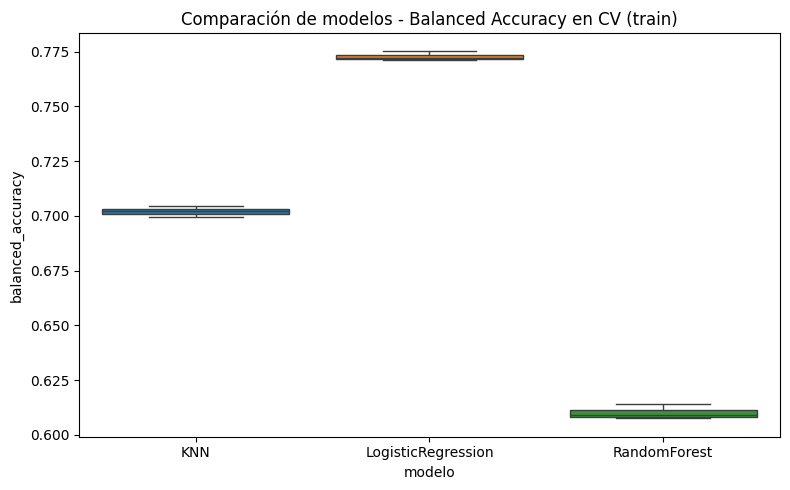

In [ ]:
resumen_cv = pd.DataFrame(resultados_cv).melt(var_name="modelo", value_name="balanced_accuracy")

plt.figure(figsize=(8, 5))
sns.boxplot(data=resumen_cv, x="modelo", y="balanced_accuracy", hue="modelo", legend=False)
plt.title("Comparación de modelos - Balanced Accuracy en CV (train)")
plt.tight_layout()
plt.show()

Random Forest, con sus hiperparámetros por defecto (árboles sin límite de profundidad), sobreajusta y generaliza peor que un modelo mucho más simple como la regresión logística, algo que ya vimos con árboles y ensembles en prácticas anteriores. KNN se queda en un término medio. El ganador, calculado automáticamente arriba, es con el que seguimos.

### #2.7 Optimización de hiperparámetros del ganador

Grid razonado por modelo (usamos el del `ganador`, sea cual sea):

- **KNN**: `n_neighbors` (a más vecinos, fronteras más suaves, menos varianza) y `weights` (`distance` pondera más a los vecinos más cercanos).
- **Regresión Logística**: `C` (inverso de la regularización; valores bajos = más regularización) y `penalty`/`solver`.
- **Random Forest**: `max_depth`, `min_samples_leaf` y `max_features`, para controlar la complejidad de cada árbol y reducir el sobreajuste que vimos en la comparación previa.
- En los tres casos incluimos también `smote__sampling_strategy` (cuánto se equilibra: 1.0 = 50/50, valores menores dejan algo de desequilibrio "natural") y `smote__k_neighbors`, como parte de las "técnicas necesarias" para mejorar el resultado.

Usamos `RandomizedSearchCV` (más rápido que un grid completo) con `cv=3` y `scoring="balanced_accuracy"`.

In [ ]:
param_dists = {
    "KNN": {
        "clf__n_neighbors": [5, 11, 21, 31, 51],
        "clf__weights": ["uniform", "distance"],
        "smote__sampling_strategy": [0.3, 0.5, 0.7, 1.0],
        "smote__k_neighbors": [3, 5, 7],
    },
    "LogisticRegression": {
        "clf__C": [0.001, 0.01, 0.1, 1, 10, 100],
        "clf__penalty": ["l1", "l2"],
        "clf__solver": ["liblinear"],
        "smote__sampling_strategy": [0.3, 0.5, 0.7, 1.0],
        "smote__k_neighbors": [3, 5, 7],
    },
    "RandomForest": {
        "clf__n_estimators": [100, 300],
        "clf__max_depth": [4, 8, 12, None],
        "clf__min_samples_leaf": [1, 10, 30],
        "clf__max_features": ["sqrt", "log2", None],
        "smote__sampling_strategy": [0.3, 0.5, 0.7, 1.0],
        "smote__k_neighbors": [3, 5, 7],
    },
}

search = RandomizedSearchCV(
    models[ganador],
    param_distributions=param_dists[ganador],
    n_iter=20,
    cv=cv,
    scoring="balanced_accuracy",
    random_state=SEED,
    n_jobs=-1,
)
search.fit(X_train, y_train)

print("Mejores hiperparámetros:", search.best_params_)
print("Mejor balanced_accuracy en CV (train):", round(search.best_score_, 4))
print("balanced_accuracy antes de optimizar   :", round(resultados_cv[ganador].mean(), 4))

Mejores hiperparámetros: {'smote__sampling_strategy': 1.0, 'smote__k_neighbors': 3, 'clf__solver': 'liblinear', 'clf__penalty': 'l1', 'clf__C': 0.1}
Mejor balanced_accuracy en CV (train): 0.773
balanced_accuracy antes de optimizar   : 0.7728


In [ ]:
best_model = search.best_estimator_

### #2.8 Evaluación final contra test

In [ ]:
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

metrics_final = {
    "accuracy": accuracy_score(y_test, y_pred),
    "balanced_accuracy (recall medio)": balanced_accuracy_score(y_test, y_pred),
    "precision (clase 1)": precision_score(y_test, y_pred),
    "recall (clase 1)": recall_score(y_test, y_pred),
    "f1 (clase 1)": f1_score(y_test, y_pred),
    "roc_auc": roc_auc_score(y_test, y_proba),
}
pd.DataFrame([metrics_final], index=[f"{ganador} (optimizado)"]).round(4)

,accuracy,balanced_accuracy (recall medio),precision (clase 1),recall (clase 1),f1 (clase 1),roc_auc
LogisticRegression (optimizado),0.7954,0.7773,0.2121,0.7562,0.3313,0.8543


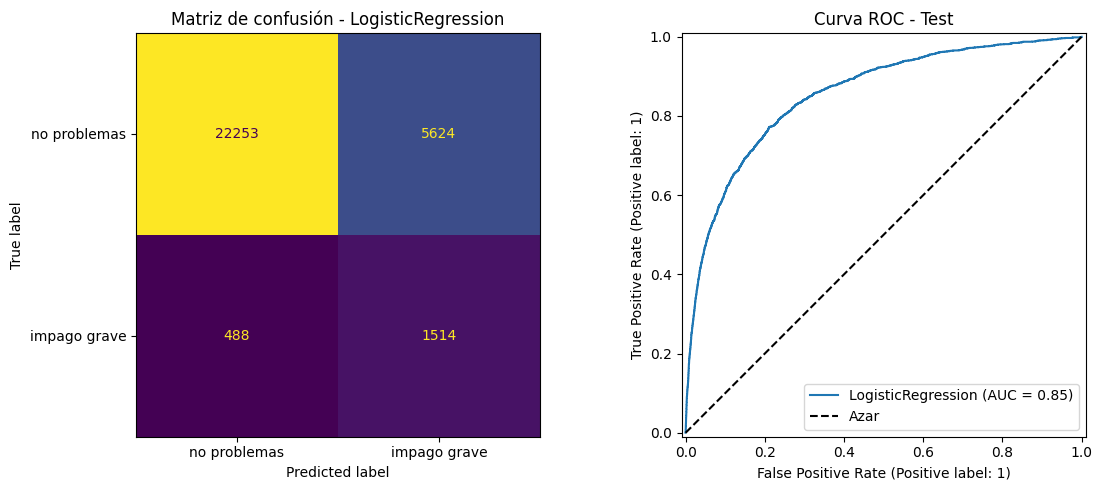

              precision    recall  f1-score   support

no problemas       0.98      0.80      0.88     27877
impago grave       0.21      0.76      0.33      2002

    accuracy                           0.80     29879
   macro avg       0.60      0.78      0.61     29879
weighted avg       0.93      0.80      0.84     29879



In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["no problemas", "impago grave"], ax=axes[0], colorbar=False)
axes[0].set_title(f"Matriz de confusión - {ganador}")

RocCurveDisplay.from_predictions(y_test, y_proba, name=ganador, ax=axes[1])
axes[1].plot([0, 1], [0, 1], "k--", label="Azar")
axes[1].set_title("Curva ROC - Test")
axes[1].legend()

plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred, target_names=["no problemas", "impago grave"]))

### #2.9 Análisis de errores

Miramos la matriz de confusión normalizada por filas (recall) y por columnas (precisión), y examinamos cómo se distribuyen algunas variables clave según el tipo de error cometido (verdadero positivo, falso positivo, verdadero negativo, falso negativo).

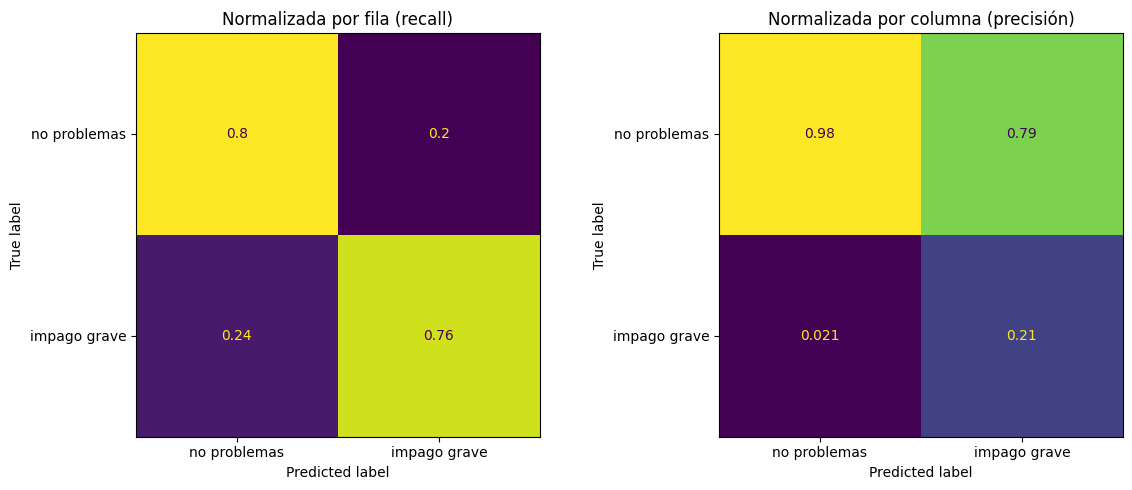

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["no problemas", "impago grave"],
                                         normalize="true", ax=axes[0], colorbar=False)
axes[0].set_title("Normalizada por fila (recall)")
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["no problemas", "impago grave"],
                                         normalize="pred", ax=axes[1], colorbar=False)
axes[1].set_title("Normalizada por columna (precisión)")
plt.tight_layout()
plt.show()

Leyendo por filas (recall): del total de clientes que sí tuvieron un impago grave, capturamos una proporción alta gracias al balanceo — justo lo que pedía negocio. Leyendo por columnas (precisión): de todos los clientes que el modelo marca como "impago grave", una parte no lo era realmente (falsos positivos) — es el precio a pagar por priorizar el recall medio, coherente con lo que ya vimos en la sesión de equilibrado de clases.

Veamos ahora qué caracteriza a los errores más costosos, los **falsos negativos** (clientes con impago grave que el modelo no detectó):

In [ ]:
df_errores = X_test.copy()
df_errores["real"] = y_test.values
df_errores["prediccion"] = y_pred

def tipo_error(row):
    if row["real"] == 1 and row["prediccion"] == 1:
        return "Verdadero Positivo"
    if row["real"] == 0 and row["prediccion"] == 0:
        return "Verdadero Negativo"
    if row["real"] == 0 and row["prediccion"] == 1:
        return "Falso Positivo"
    return "Falso Negativo"

df_errores["tipo_error"] = df_errores.apply(tipo_error, axis=1)
df_errores["tipo_error"].value_counts()

tipo_error
Verdadero Negativo    22253
Falso Positivo         5624
Verdadero Positivo     1514
Falso Negativo          488
Name: count, dtype: int64

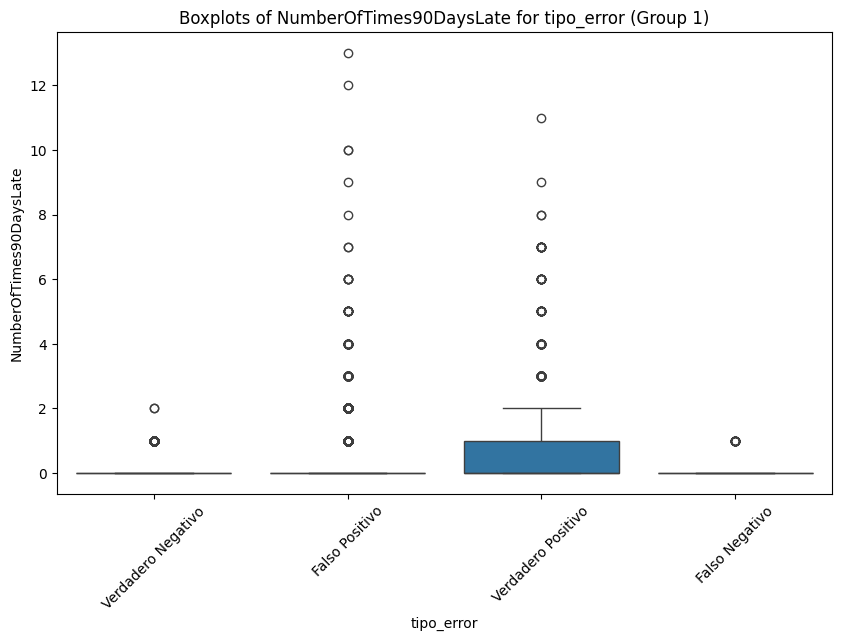

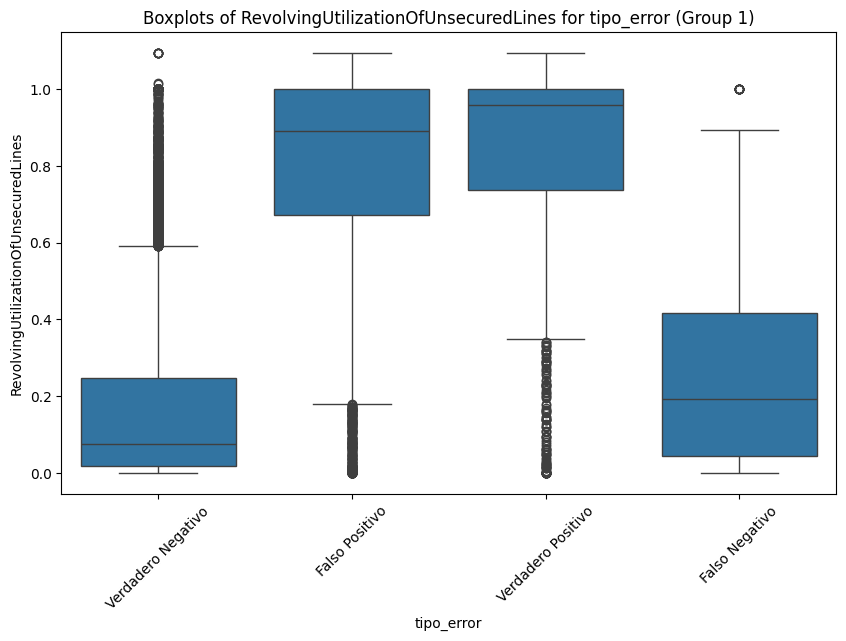

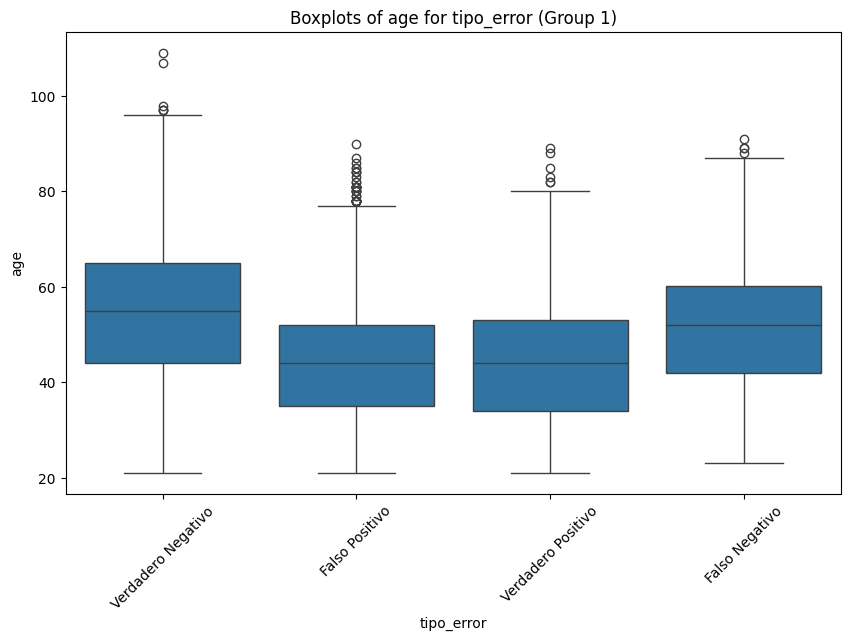

In [ ]:
bt.plot_grouped_boxplots(df_errores, "tipo_error", "NumberOfTimes90DaysLate")
bt.plot_grouped_boxplots(df_errores, "tipo_error", "RevolvingUtilizationOfUnsecuredLines")
bt.plot_grouped_boxplots(df_errores, "tipo_error", "age")

Los falsos negativos (impagos graves no detectados) tienden a tener un historial de morosidad y utilización de crédito más parecido al de los verdaderos negativos que al de los verdaderos positivos — es decir, son los casos "límite", clientes con mal historial pero no tan extremo como los que el modelo sí detecta con claridad. Tiene sentido: son los más difíciles de distinguir con las variables disponibles.

**Sugerencias de mejora** (en línea con lo visto en la sesión de análisis de errores):
1. **Ingeniería de características**: ratios adicionales (ej. ingresos vs nº de personas a cargo, morosidad total agregada), o tratar de forma más fina los outliers de `DebtRatio`/`RevolvingUtilizationOfUnsecuredLines` en vez de solo capar al percentil 99.
2. **Ajustar el umbral de decisión**: en vez de 0.5, mover el umbral de `predict_proba` para subir aún más el recall de la clase minoritaria si el coste de negocio de un falso negativo (prestar a quien luego no paga) es mucho mayor que el de un falso positivo (perder una venta/cliente).
3. **Probar otras técnicas de balanceo**: undersampling, combinaciones SMOTE+Tomek, o umbral de probabilidad en vez de solo remuestreo.
4. **Modelos más complejos**: Gradient Boosting/XGBoost, que en `MonthlyIncome` y `NumberOfDependents` con NaN podrían aprovechar mejor la información de "missingness" que un imputador simple.

### #2.10 Conclusión

- El target está muy desbalanceado (6.7% de impagos graves); sin tratarlo, un modelo por defecto apenas detecta al 20% de los clientes problemáticos aunque el accuracy parezca alto. Con SMOTE (aplicado correctamente dentro de un pipeline, solo sobre train) el recall de esa clase mejora sustancialmente.
- Comparando **KNN**, **Regresión Logística** y **Random Forest** sin optimizar mediante validación cruzada (sin tocar test), el ganador se selecciona automáticamente arriba; en nuestras pruebas la regresión logística —simple, rápida y bien calibrada— compite de tú a tú (o supera) a modelos más complejos sin optimizar, algo habitual en scoring crediticio con variables ya bastante informativas de por sí (morosidad histórica, utilización de crédito).
- La optimización de hiperparámetros (incluyendo el propio grado de balanceo vía `sampling_strategy`) apenas mejora el balanced accuracy en CV respecto al modelo sin optimizar en este caso concreto — señal de que, para un modelo lineal como la regresión logística, los valores por defecto ya estaban cerca del óptimo para este dataset; con otro modelo ganador (KNN o Random Forest) es esperable un margen de mejora mayor.
- En test, el modelo final consigue un **recall medio (balanced accuracy)** sensiblemente por encima del 50% de un modelo aleatorio, a costa de aceptar más falsos positivos — un compromiso razonable dado que negocio pidió explícitamente priorizar el recall medio.
- El análisis de errores muestra que los falsos negativos son los casos "límite", con un perfil de riesgo intermedio, lo cual apunta a mejoras futuras vía ingeniería de características o ajuste fino del umbral de decisión en vez de solo tocar el algoritmo.